# Neighborhood Overlap Analysis

This notebook analyzes the `comparison_quality-*.csv` output from the native RAG vs two-call baseline benchmark.

The main metric here is:

`mean_pairwise_neighborhood_overlap`

Interpretation:

- Lower overlap means the selected seed nodes have less shared 1-hop graph context.
- If native RAG has lower overlap than the baseline, that supports the claim that the reranker is selecting less redundant seed neighborhoods.
- Rows with `top_k = 1` cannot have pairwise overlap because there is only one seed, so those rows are filtered out for this analysis.

This notebook intentionally ignores `mean_seed_ann_score` because native and baseline scores are currently not on the same scale.

## Setup

If this notebook kernel does not already have the plotting packages installed, run:

```bash
pip install pandas matplotlib seaborn
```

If you are using the benchmark virtual environment, you can also install them into `.venv` from the `neo4j-rag-benchmark` directory.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("ggplot")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

Matplotlib is building the font cache; this may take a moment.


## Load Data

Update `CSV_PATH` if you want to analyze a newer comparison-quality run.

The default path below points to your current result file.

In [11]:
BENCHMARK_ROOT = Path("..").resolve()
CSV_PATH = BENCHMARK_ROOT / "results" / "eval" / "comparison_quality-20260416-004654.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Could not find quality CSV: {CSV_PATH}")

raw_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(raw_df):,} rows from {CSV_PATH}")
raw_df.head()

Loaded 1,200 rows from /Users/chelseahuynh/CSCI543-Project-2-Neo4j/neo4j/neo4j-rag-benchmark/results/eval/comparison_quality-20260416-004654.csv


,query_id,top_k,depth,native_seed_count,baseline_seed_count,native_mean_seed_ann_score,baseline_mean_seed_ann_score,seed_ann_score_difference,native_mean_pairwise_neighborhood_overlap,baseline_mean_pairwise_neighborhood_overlap,neighborhood_overlap_difference,native_row_count,baseline_row_count,row_count_difference,row_count_ratio,result_jaccard_overlap,shared_result_count,native_only_count,baseline_only_count,native_unique_label_count,baseline_unique_label_count,native_label_entropy,baseline_label_entropy,native_majority_label_fraction,baseline_majority_label_fraction
0,paper-93434-topk-1-depth-0,1,0,1,1,1.0,0.999703,0.000297,NaN,NaN,NaN,1,1,0,1.000000,0.000000,0,1,1,1,1,0.000000,0.000000,1.000000,1.000000
1,paper-93434-topk-1-depth-1,1,1,1,1,1.0,0.999703,0.000297,NaN,NaN,NaN,10,31,-21,0.322581,0.000000,0,10,31,2,2,0.468996,0.205593,0.900000,0.967742
2,paper-93434-topk-1-depth-2,1,2,1,1,1.0,0.999703,0.000297,NaN,NaN,NaN,180,747,-567,0.240964,0.051020,45,135,702,7,14,0.877432,0.912614,0.811111,0.817938
3,paper-93434-topk-3-depth-0,3,0,3,3,1.0,0.984368,0.015632,0.0,0.009009,-0.009009,3,3,0,1.000000,0.000000,0,3,3,1,1,0.000000,0.000000,1.000000,1.000000
4,paper-93434-topk-3-depth-1,3,1,3,3,1.0,0.984368,0.015632,0.0,0.009009,-0.009009,29,44,-15,0.659091,0.042857,3,26,41,3,3,0.999700,0.312220,0.724138,0.954545


## Data Cleaning

For neighborhood-overlap analysis, we filter to rows where:

- `top_k > 1`
- native overlap exists
- baseline overlap exists

Then we compute:

`overlap_reduction = baseline_overlap - native_overlap`

So:

- Positive `overlap_reduction` means native RAG had lower overlap than baseline.
- Zero means no difference.
- Negative means native RAG had higher overlap than baseline.

In [19]:
NATIVE_COL = "native_mean_pairwise_neighborhood_overlap"
BASELINE_COL = "baseline_mean_pairwise_neighborhood_overlap"
DIFF_COL = "neighborhood_overlap_difference"

# Force numeric conversion in case blank fields or null-like values exist.
for col in ["top_k", "depth", NATIVE_COL, BASELINE_COL, DIFF_COL]:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

overlap_df = raw_df[
    (raw_df["top_k"] > 1)
    & raw_df[NATIVE_COL].notna()
    & raw_df[BASELINE_COL].notna()
].copy()

overlap_df["overlap_reduction"] = overlap_df[BASELINE_COL] - overlap_df[NATIVE_COL]
overlap_df["winner"] = overlap_df["overlap_reduction"].map(
    lambda x: "native_lower" if x > 0 else ("tie" if x == 0 else "baseline_lower")
)

print(f"Rows before cleaning: {len(raw_df):,}")
print(f"Rows after overlap filter: {len(overlap_df):,}")
overlap_df[["query_id", "top_k", "depth", NATIVE_COL, BASELINE_COL, "overlap_reduction", "winner"]].head()

Rows before cleaning: 1,200
Rows after overlap filter: 900


,query_id,top_k,depth,native_mean_pairwise_neighborhood_overlap,baseline_mean_pairwise_neighborhood_overlap,overlap_reduction,winner
3,paper-93434-topk-3-depth-0,3,0,0.0,0.009009,0.009009,native_lower
4,paper-93434-topk-3-depth-1,3,1,0.0,0.009009,0.009009,native_lower
5,paper-93434-topk-3-depth-2,3,2,0.0,0.009009,0.009009,native_lower
6,paper-93434-topk-5-depth-0,5,0,0.0,0.017284,0.017284,native_lower
7,paper-93434-topk-5-depth-1,5,1,0.0,0.017284,0.017284,native_lower


## Summary Statistics

These numbers are the fastest way to describe the trend in the report.

In [20]:
summary = {
    "row_count": len(overlap_df),
    "native_mean_overlap": overlap_df[NATIVE_COL].mean(),
    "baseline_mean_overlap": overlap_df[BASELINE_COL].mean(),
    "mean_overlap_reduction": overlap_df["overlap_reduction"].mean(),
    "median_overlap_reduction": overlap_df["overlap_reduction"].median(),
    "native_lower_fraction": (overlap_df["overlap_reduction"] > 0).mean(),
    "tie_fraction": (overlap_df["overlap_reduction"] == 0).mean(),
    "baseline_lower_fraction": (overlap_df["overlap_reduction"] < 0).mean(),
}

pd.Series(summary).to_frame("value")

,value
row_count,900.000000
native_mean_overlap,0.000136
baseline_mean_overlap,0.018191
mean_overlap_reduction,0.018056
median_overlap_reduction,0.004288
native_lower_fraction,0.586667
tie_fraction,0.413333
baseline_lower_fraction,0.000000


In [21]:
# Optional: summarize by top_k, because seed overlap is most meaningful as the number of selected seeds changes.
by_topk = overlap_df.groupby("top_k", as_index=False).agg(
    cases=("query_id", "count"),
    native_mean_overlap=(NATIVE_COL, "mean"),
    baseline_mean_overlap=(BASELINE_COL, "mean"),
    mean_overlap_reduction=("overlap_reduction", "mean"),
    median_overlap_reduction=("overlap_reduction", "median"),
    native_lower_fraction=("overlap_reduction", lambda s: (s > 0).mean()),
)
by_topk

,top_k,cases,native_mean_overlap,baseline_mean_overlap,mean_overlap_reduction,median_overlap_reduction,native_lower_fraction
0,3,300,0.000148,0.026577,0.026429,0.000000,0.42
1,5,300,0.000197,0.016313,0.016115,0.004287,0.56
2,10,300,0.000061,0.011684,0.011623,0.005554,0.78


## Plot 1: Paired Scatter Plot

This plot compares native and baseline overlap for each query case.

How to read it:

- Points below the diagonal mean native RAG had lower neighborhood overlap.
- Points on the diagonal mean both methods were equal.
- Points above the diagonal mean baseline had lower overlap.

This is the strongest query-level visualization because every point is a direct A/B comparison.

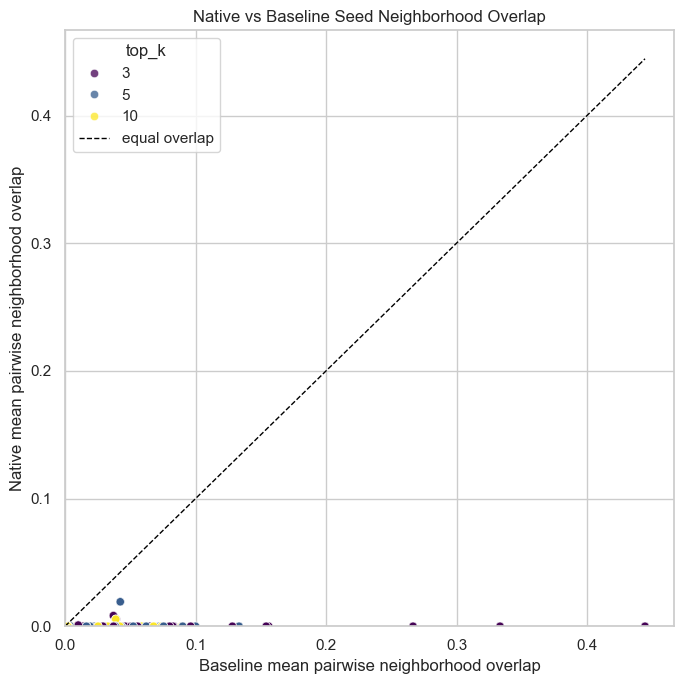

In [26]:
fig, ax = plt.subplots(figsize=(7, 7))

if sns:
    sns.scatterplot(
        data=overlap_df,
        x=BASELINE_COL,
        y=NATIVE_COL,
        hue="top_k",
        palette="viridis",
        alpha=0.75,
        ax=ax,
    )
else:
    scatter = ax.scatter(
        overlap_df[BASELINE_COL],
        overlap_df[NATIVE_COL],
        c=overlap_df["top_k"],
        alpha=0.75,
    )
    fig.colorbar(scatter, ax=ax, label="top_k")

max_val = max(overlap_df[BASELINE_COL].max(), overlap_df[NATIVE_COL].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", color="black", linewidth=1, label="equal overlap")

ax.set_title("Native vs Baseline Seed Neighborhood Overlap")
ax.set_xlabel("Baseline mean pairwise neighborhood overlap")
ax.set_ylabel("Native mean pairwise neighborhood overlap")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(title="top_k", loc="best")
plt.tight_layout()
plt.show()

## Plot 2: Overlap Reduction Distribution

This histogram shows the distribution of:

`baseline_overlap - native_overlap`

How to read it:

- Values greater than `0` mean native RAG reduced neighborhood overlap.
- Values equal to `0` mean no change.
- Values less than `0` mean native RAG had more overlap than baseline.

A distribution concentrated to the right of zero supports the claim that native RAG reduces redundant seed neighborhoods.

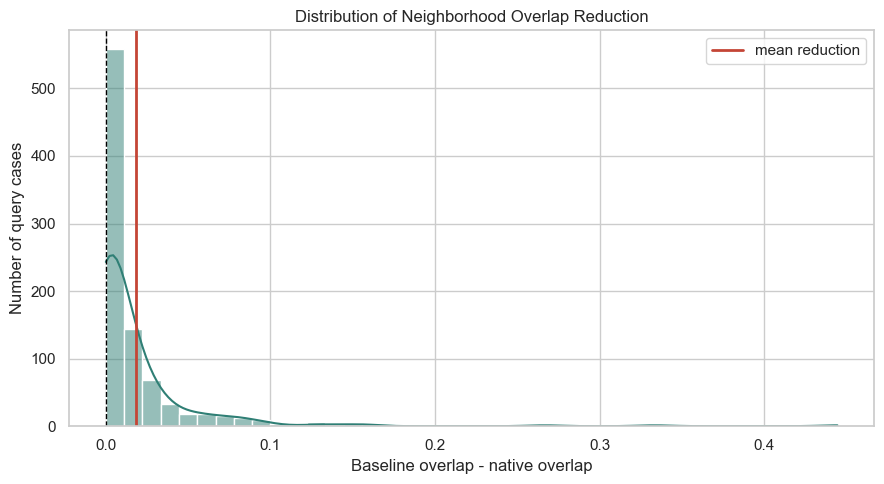

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.histplot(overlap_df["overlap_reduction"], bins=40, kde=True, ax=ax, color="#2f7f75")
else:
    ax.hist(overlap_df["overlap_reduction"], bins=40, color="#2f7f75", alpha=0.85)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(overlap_df["overlap_reduction"].mean(), color="#c44536", linestyle="-", linewidth=2, label="mean reduction")
ax.set_title("Distribution of Neighborhood Overlap Reduction")
ax.set_xlabel("Baseline overlap - native overlap")
ax.set_ylabel("Number of query cases")
ax.legend()
plt.tight_layout()
plt.show()

## Plot 3: Mean Overlap by `top_k`

This plot shows whether the overlap behavior changes as more seed nodes are requested.

How to read it:

- If baseline overlap rises with `top_k`, the baseline is selecting more seeds from overlapping graph neighborhoods.
- If native remains lower, the native reranker is preserving more neighborhood diversity as `top_k` grows.

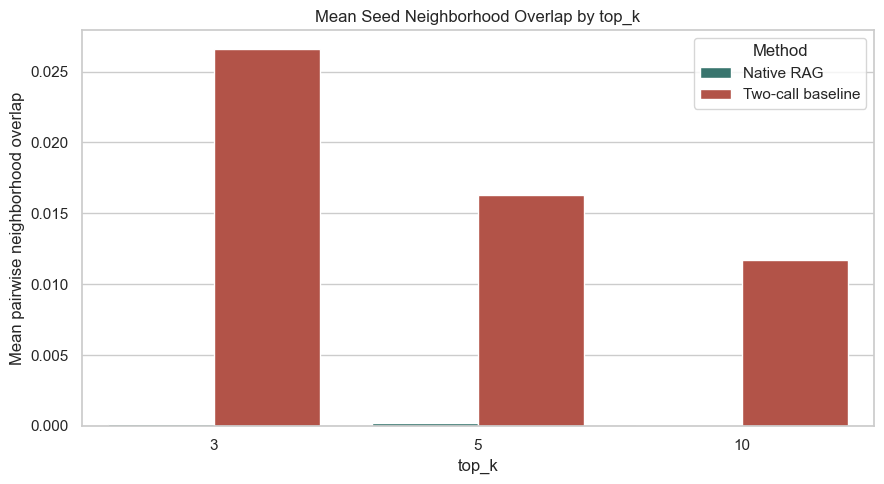

In [27]:
plot_df = by_topk.melt(
    id_vars=["top_k"],
    value_vars=["native_mean_overlap", "baseline_mean_overlap"],
    var_name="method",
    value_name="mean_overlap",
)
plot_df["method"] = plot_df["method"].map({
    "native_mean_overlap": "Native RAG",
    "baseline_mean_overlap": "Two-call baseline",
})

fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.barplot(data=plot_df, x="top_k", y="mean_overlap", hue="method", ax=ax, palette=["#2f7f75", "#c44536"])
else:
    pivot = plot_df.pivot(index="top_k", columns="method", values="mean_overlap")
    pivot.plot(kind="bar", ax=ax, color=["#2f7f75", "#c44536"])

ax.set_title("Mean Seed Neighborhood Overlap by top_k")
ax.set_xlabel("top_k")
ax.set_ylabel("Mean pairwise neighborhood overlap")
ax.legend(title="Method")
plt.tight_layout()
plt.show()

## Optional Plot 4: Win/Tie/Loss by `top_k`

This plot summarizes how often native RAG had lower, equal, or higher neighborhood overlap than baseline.

This can be useful if the mean is affected by a few large baseline-overlap outliers.

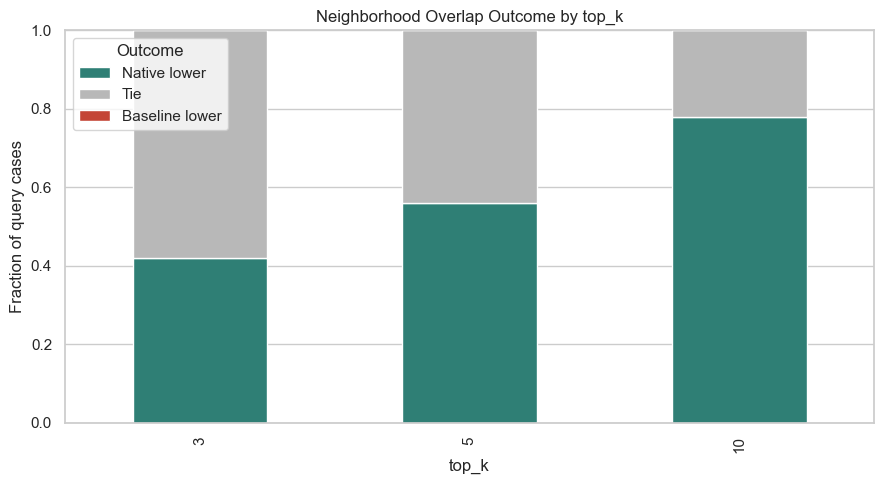

winner,native_lower,tie,baseline_lower
top_k,,,
3,0.42,0.58,0.0
5,0.56,0.44,0.0
10,0.78,0.22,0.0


In [18]:
win_df = overlap_df.groupby(["top_k", "winner"]).size().reset_index(name="count")
win_df["fraction"] = win_df["count"] / win_df.groupby("top_k")["count"].transform("sum")

winner_order = ["native_lower", "tie", "baseline_lower"]
win_pivot = win_df.pivot(index="top_k", columns="winner", values="fraction").reindex(columns=winner_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
win_pivot.plot(kind="bar", stacked=True, ax=ax, color=["#2f7f75", "#b8b8b8", "#c44536"])
ax.set_title("Neighborhood Overlap Outcome by top_k")
ax.set_xlabel("top_k")
ax.set_ylabel("Fraction of query cases")
ax.legend(title="Outcome", labels=["Native lower", "Tie", "Baseline lower"])
plt.tight_layout()
plt.show()

win_pivot

## Suggested Report Wording

You can adapt this depending on the exact values from your final run:

> We compared the mean pairwise 1-hop neighborhood overlap among selected seed nodes for native RAG and the two-call baseline. Lower overlap indicates that selected seeds cover less redundant local graph context. After filtering to cases with `top_k > 1`, native RAG showed lower average neighborhood overlap than the baseline. This suggests that the native reranking step is changing seed selection in the intended direction: it tends to select seeds from more distinct graph neighborhoods rather than selecting vector-similar seeds clustered around the same local citation context.

Important caveat:

> This metric validates behavior relative to the graph structure of OGBN-Arxiv; it does not directly measure semantic answer quality. It should be interpreted as a diversity/redundancy signal rather than an absolute accuracy metric.